# Diabetes (Playground S5E12): Conv1D CNN-3 vs CNN-5 in TensorFlow and PyTorch

**Author:** Nguyễn Văn Trường (B23DCCE095) · E23CNPM02 · Intelligent System Development · Assignment 05

**Data:** the Kaggle competition [Playground Series S5E12, "Diabetes Prediction Challenge"](https://www.kaggle.com/competitions/playground-series-s5e12).
`train.csv` holds 700,000 patients described by 24 features (age, BMI, blood pressure, cholesterol, lifestyle, demographics), along with
the target `diagnosed_diabetes` (0 = no, 1 = yes). A stratified sample of **300,000** rows is used here.
Kaggle produced this data synthetically from a real dataset, so the numbers describe the benchmark rather than clinical accuracy.

A table has no pixel grid, so the CNNs in this notebook rely on **1-D convolutions** sliding across the list of features.

| Run ID | Framework | Model |
|---|---|---|
| `DB-TF-CNN-3` | TensorFlow/Keras | 3 Conv1D layers |
| `DB-TF-CNN-5` | TensorFlow/Keras | 5 Conv1D layers |
| `DB-PT-CNN-3` | PyTorch | 3 Conv1D layers |
| `DB-PT-CNN-5` | PyTorch | 5 Conv1D layers |
| `DB-TF-MLP` | TensorFlow/Keras | baseline without convolution (section 6) |

Sections 1–5 walk through the method; the results are covered in sections 6–7.

## 1. Setup

Seed 42 is applied everywhere (identical weights, batch order and dropout on every rerun). PyTorch device selection: `cuda` → `mps` → `cpu`;
TensorFlow picks up an NVIDIA (Linux/WSL2) or Apple GPU automatically, otherwise it falls back to the CPU. TensorFlow only claims GPU memory
as needed, so PyTorch is able to share the same GPU. `A5_SMOKE=1` triggers a quick test run.

In [1]:
import copy
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEED = 42
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import keras
from keras import layers

keras.utils.set_random_seed(SEED)

import torch
import torch.nn as nn

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))
print("PyTorch", torch.__version__, "| device:", DEVICE)

TensorFlow 2.21.0 | GPUs: []
PyTorch 2.14.0+cpu | device: cpu


**Helper functions** (no model code here): project paths, the saved split, test metrics, result files and plots.
Settings common to both frameworks: batch size 256, up to 20 epochs, early-stopping patience of 3, learning rate 0.001.

In [2]:
import json
import os
import random
from pathlib import Path

from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

SMOKE = os.environ.get("A5_SMOKE") == "1"          # fast sanity check: a small subsample, 2 epochs


def find_root():
    """assignment_05/ is the nearest ancestor of the working directory that has dataset/ and notebook/."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "dataset").is_dir() and (p / "notebook").is_dir():
            return p
    return here.parent


ROOT = find_root()
DATA_DIR = Path(os.environ.get("A5_DATA_DIR", ROOT / "dataset"))
RESULTS_DIR = ROOT / "notebook" / "results" / ("smoke" if SMOKE else "")
MODELS_DIR = ROOT / "notebook" / "models" / ("smoke" if SMOKE else "")
FIG_DIR = ROOT / "report" / "images" / ("smoke" if SMOKE else "")
for d in (RESULTS_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
EPOCHS = 2 if SMOKE else 20
PATIENCE = 3
LEARNING_RATE = 1e-3
SMOKE_SIZE = {"train": 2000, "validation": 500, "test": 500}

random.seed(SEED)
np.random.seed(SEED)
print("project folder:", ROOT, "| smoke run:", SMOKE, "| epochs:", EPOCHS, "| batch size:", BATCH_SIZE)


def find_file(code, name):
    """Locate `name` anywhere under dataset/<code>/ (unzipping sometimes adds an extra subfolder)."""
    base = DATA_DIR / code.lower()
    hits = sorted(base.rglob(name))
    if not hits:
        raise FileNotFoundError(f"{name} not found under {base}; see dataset/README.md")
    return hits[0]


def make_or_load_splits(code, y, n_sample=None):
    """Stratified 70/15/15 split of row indices, cached once to dataset/<code>/splits.npz."""
    path = DATA_DIR / code.lower() / "splits.npz"
    n_sample = min(n_sample or len(y), len(y))
    splits = None
    if path.exists():
        saved = np.load(path)
        splits = {k: saved[k] for k in ("train", "validation", "test")}
        if sum(len(v) for v in splits.values()) != n_sample:
            splits = None
    if splits is None:
        idx = np.arange(len(y))
        if n_sample < len(y):
            idx, _ = train_test_split(idx, train_size=n_sample, stratify=y, random_state=SEED)
        train, rest = train_test_split(idx, train_size=0.70, stratify=y[idx], random_state=SEED)
        val, test = train_test_split(rest, test_size=0.50, stratify=y[rest], random_state=SEED)
        splits = {"train": np.sort(train), "validation": np.sort(val), "test": np.sort(test)}
        np.savez(path, **splits)
    if SMOKE:
        rng = np.random.default_rng(SEED)
        splits = {k: np.sort(rng.choice(v, min(SMOKE_SIZE[k], len(v)), replace=False)) for k, v in splits.items()}
    return splits


def classification_metrics(y_true, y_pred, y_score=None, binary=False):
    """Accuracy plus macro precision/recall/F1; binary tasks also get positive-class F1, ROC-AUC and AP."""
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if binary:
        m["f1_positive"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        m["roc_auc"] = roc_auc_score(y_true, y_score)
        m["average_precision"] = average_precision_score(y_true, y_score)
    return {k: float(v) for k, v in m.items()}


class Stopwatch:
    def __enter__(self):
        self._start = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.seconds = time.perf_counter() - self._start


def save_result(record):
    (RESULTS_DIR / f"{record['run_id']}.json").write_text(json.dumps(record, indent=2), encoding="utf-8")


def load_results(run_ids):
    paths = [RESULTS_DIR / f"{rid}.json" for rid in run_ids]
    return [json.loads(p.read_text(encoding="utf-8")) for p in paths if p.exists()]


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def plot_history(history, run_id):
    """Two-panel figure: loss and accuracy per epoch, train vs validation."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    epochs = np.arange(1, len(history["loss"]) + 1)
    for ax, key, title in [(axes[0], "loss", "Loss"), (axes[1], "accuracy", "Accuracy")]:
        ax.plot(epochs, history[key], marker="o", label="train")
        ax.plot(epochs, history[f"val_{key}"], marker="o", label="validation")
        ax.set_title(f"{run_id}: {title}"); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); savefig(fig, f"{run_id}_curves"); plt.show()


def plot_confusion(y_true, y_pred, labels, run_id):
    """Row-normalized confusion matrix: rows are the true class, columns the predicted class."""
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    shown = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    many = len(labels) > 12
    size = max(4.5, 0.28 * len(labels))
    fig, ax = plt.subplots(figsize=(size + 1, size))
    im = ax.imshow(shown, cmap="Purples", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90 if many else 0, fontsize=7 if many else 9)
    ax.set_yticklabels(labels, fontsize=7 if many else 9)
    if not many:
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, f"{shown[i, j]:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if shown[i, j] > 0.5 else "black")
    ax.set_xlabel("predicted class"); ax.set_ylabel("true class")
    ax.set_title(f"{run_id}: confusion matrix (row-normalized)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout(); savefig(fig, f"{run_id}_confusion"); plt.show()
    return cm


def results_table(records):
    rows = []
    for r in records:
        row = {"run_id": r["run_id"], "framework": r["framework"], "model": r["model"], "params": r["params"],
               "epochs": r["epochs_run"], "time_per_epoch_s": r["time_per_epoch_s"],
               "train_time_s": r["train_time_s"], "inference_ms_per_1k": r["inference_ms_per_1k"]}
        row.update(r["test_metrics"])
        rows.append(row)
    return pd.DataFrame(rows).set_index("run_id")

project folder: E:\CODING\IS_AI\intelligent_system_assignments\assignment_05 | smoke run: False | epochs: 20 | batch size: 256


In [3]:
DATASET = "DB"
MODELS = ["CNN-3", "CNN-5"]
FRAMEWORKS = ["TF", "PT"]
RUN_IDS = [f"{DATASET}-{fw}-{m}" for fw in FRAMEWORKS for m in MODELS]
RUN_IDS

BASELINE_ID = f"{DATASET}-TF-MLP"

## 2. Data

### 2.1 Load

| Column group | Count | Examples | Treatment (2.3) |
|---|---|---|---|
| numeric | 15 | age, bmi, systolic_bp, triglycerides, sleep_hours_per_day | standardize |
| categorical (text) | 6 | gender, ethnicity, smoking_status, income_level | one-hot |
| binary 0/1 | 3 | family_history_diabetes, hypertension_history | keep |
| `id` | 1 | row number | drop |
| target | 1 | `diagnosed_diabetes` | `y` |

Labels exist only in `train.csv` (the competition's `test.csv` has none), so every split is carved out of it.

In [4]:
raw = pd.read_csv(find_file(DATASET, "train.csv"))
TARGET = "diagnosed_diabetes"
CATEGORICAL = ["gender", "ethnicity", "education_level", "income_level", "smoking_status", "employment_status"]
BINARY = ["family_history_diabetes", "hypertension_history", "cardiovascular_history"]
NUMERIC = [c for c in raw.columns if c not in CATEGORICAL + BINARY + ["id", TARGET]]

y_raw = raw[TARGET].astype(np.int64).to_numpy()
CLASS_LABELS = ["no diabetes (0)", "diabetes (1)"]
print("rows:", len(raw), "| numeric:", len(NUMERIC), "| categorical:", len(CATEGORICAL), "| binary:", len(BINARY),
      "| missing values:", int(raw.isna().sum().sum()))
raw.head()

rows: 700000 | numeric: 15 | categorical: 6 | binary: 3 | missing values: 0


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


### 2.2 Sample 300,000 rows and split 70 / 15 / 15

Both steps use **stratified** sampling: if 60% of all rows are diabetic, the sample and each split stay ~60% diabetic too.
train (210k) updates the weights · validation (45k) decides when to stop training · test (45k) provides the final score.
The row indices are saved in `dataset/db/splits.npz`, so TensorFlow and PyTorch train and test on identical rows.

In [5]:
splits = make_or_load_splits(DATASET, y_raw, n_sample=300_000)
df_train, df_val, df_test = (raw.iloc[splits[k]] for k in ("train", "validation", "test"))
y_train, y_val, y_test = (y_raw[splits[k]] for k in ("train", "validation", "test"))
pd.DataFrame({"rows": [len(y_train), len(y_val), len(y_test)],
              "diabetes share": [y_train.mean(), y_val.mean(), y_test.mean()]},
             index=["train", "validation", "test"]).round(4)

,rows,diabetes share
train,210000,0.6233
validation,45000,0.6233
test,45000,0.6233


### 2.3 Turn each row into numbers

- **Standardize numeric columns:** `z = (x − μ) / σ`, where μ and σ come from the **training rows only**.
  Example: BMI has μ = 25.9, σ = 2.9, so a BMI of 31.7 turns into `(31.7 − 25.9) / 2.9 = 2.0` ("2 standard deviations above average").
  Skipping this step would let triglycerides (~100–300) dominate a 0/1 flag purely because of scale.
- **One-hot categorical columns:** one 0/1 column per category.
  `smoking_status = "Former"` becomes `Current 0, Former 1, Never 0`. No artificial ordering (Never < Former < Current) is introduced.
- **Binary flags** are left as 0/1.
- Computing μ, σ and the category list from training rows only prevents **data leakage** (test rows must never
  influence the preprocessing).

Result: each patient becomes a vector of `d` numbers (roughly 40). For Conv1D this is treated as a length-`d` sequence with
1 channel: Keras uses `(N, d, 1)`, PyTorch uses `(N, 1, d)`.

The cell below shows one real training row before and after this transformation.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer([
    ("numeric", StandardScaler(), NUMERIC),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("binary", "passthrough", BINARY),
])
preprocess.fit(df_train)                                   # mu, sigma and categories: fit on training rows only

X_train, X_val, X_test = (preprocess.transform(d).astype(np.float32) for d in (df_train, df_val, df_test))
FEATURE_NAMES = [n.split("__", 1)[1] for n in preprocess.get_feature_names_out()]
N_FEATURES = X_train.shape[1]

X_train_tf, X_val_tf, X_test_tf = (x[:, :, None] for x in (X_train, X_val, X_test))    # (N, d, 1)
X_train_pt, X_val_pt, X_test_pt = (x[:, None, :] for x in (X_train, X_val, X_test))    # (N, 1, d)
print("d =", N_FEATURES, "features | TF:", X_train_tf.shape, "| PT:", X_train_pt.shape)

d = 42 features | TF: (210000, 42, 1) | PT: (210000, 1, 42)


In [7]:
row = 0
before = df_train.iloc[row][["age", "bmi", "triglycerides", "smoking_status", "family_history_diabetes"]]
after = pd.Series(X_train[row], index=FEATURE_NAMES)
after = after[["age", "bmi", "triglycerides"] + [f for f in FEATURE_NAMES if f.startswith("smoking_status")]
              + ["family_history_diabetes"]]
display(before.to_frame("raw value").T)
display(after.round(3).to_frame("model input").T)

,age,bmi,triglycerides,smoking_status,family_history_diabetes
raw value,31,33.4,102,Current,0


,age,bmi,triglycerides,smoking_status_Current,smoking_status_Former,smoking_status_Never,family_history_diabetes
model input,-1.658,2.628,-0.854,1.0,0.0,0.0,0.0


### 2.4 Class weights

When one class dominates, the loss ends up dominated by it too. Each class receives `w_c = N / (2 · N_c)`:
e.g. 62% diabetic / 38% not gives `w_1 = 1 / (2·0.62) = 0.81`, `w_0 = 1 / (2·0.38) = 1.32`.
Every row's loss is scaled by its class weight so both classes contribute equally overall.
This only applies when the smaller class falls below 40%; otherwise all weights stay 1. The same weights are reused in both frameworks.

In [8]:
counts = np.bincount(y_train, minlength=2)
minority_share = counts.min() / counts.sum()
USE_CLASS_WEIGHTS = minority_share < 0.40
class_weight = (counts.sum() / (2 * counts)) if USE_CLASS_WEIGHTS else np.ones(2)
w_train = class_weight[y_train].astype(np.float32)
print("class counts:", counts, "| minority share:", round(minority_share, 3),
      "| weights used:", USE_CLASS_WEIGHTS, "| w_0, w_1 =", class_weight.round(3))

class counts: [ 79108 130892] | minority share: 0.377 | weights used: True | w_0, w_1 = [1.327 0.802]


## 3. Look at the data (training rows only)

**Target balance** per split: this drives the class weights (2.4) and explains why ROC-AUC and F1 are reported alongside accuracy.

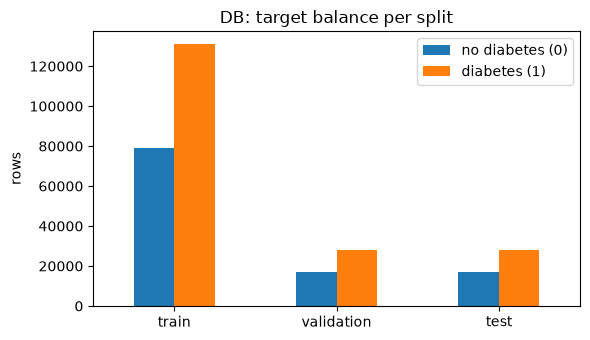

,train,validation,test
no diabetes (0),79108,16951,16952
diabetes (1),130892,28049,28048


In [9]:
balance = pd.DataFrame({k: np.bincount(y_raw[v], minlength=2) for k, v in splits.items()}, index=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(6, 3.5))
balance.T.plot.bar(ax=ax, rot=0)
ax.set_ylabel("rows"); ax.set_title(f"{DATASET}: target balance per split")
fig.tight_layout(); savefig(fig, f"{DATASET}_target_balance"); plt.show()
balance

**Which numeric features separate the classes?** For each feature: `(mean in diabetic rows − mean in non-diabetic rows) / σ`.
A bar at +0.5 means diabetic patients sit, on average, half a standard deviation higher. The second figure shows the
full distributions for the two strongest features.

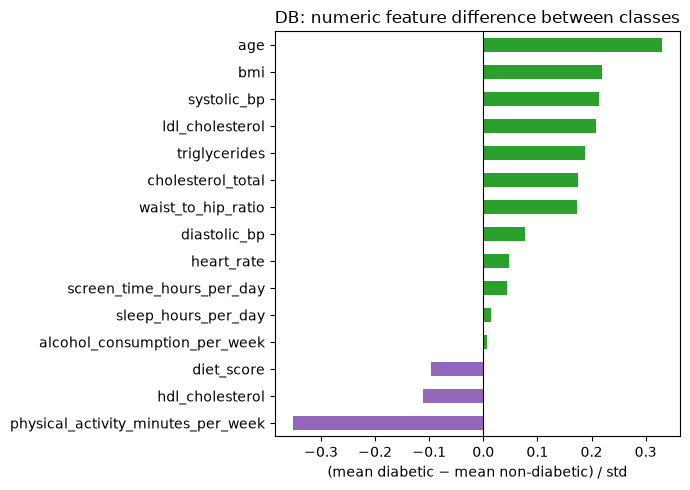

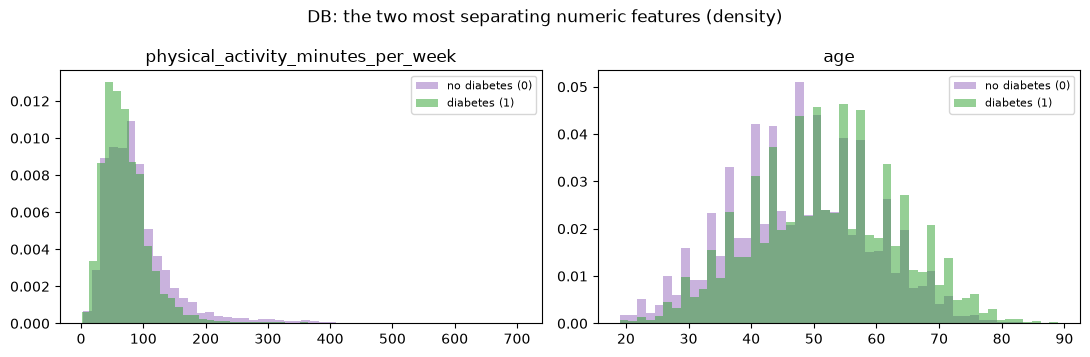

In [10]:
std = df_train[NUMERIC].std()
effect = ((df_train.loc[y_train == 1, NUMERIC].mean() - df_train.loc[y_train == 0, NUMERIC].mean()) / std)
effect = effect.sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
effect.plot.barh(ax=ax, color=np.where(effect > 0, "tab:green", "tab:purple"))
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("(mean diabetic − mean non-diabetic) / std")
ax.set_title(f"{DATASET}: numeric feature difference between classes")
fig.tight_layout(); savefig(fig, f"{DATASET}_feature_effect"); plt.show()

top2 = effect.abs().sort_values(ascending=False).index[:2]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col in zip(axes, top2):
    for cls, color in [(0, "tab:purple"), (1, "tab:green")]:
        ax.hist(df_train.loc[y_train == cls, col], bins=50, density=True, alpha=0.5, color=color, label=CLASS_LABELS[cls])
    ax.set_title(col); ax.legend(fontsize=8)
fig.suptitle(f"{DATASET}: the two most separating numeric features (density)")
fig.tight_layout(); savefig(fig, f"{DATASET}_top_features"); plt.show()

**Correlation** `r = cov(a, b) / (σ_a σ_b)`, ranging from −1 to +1, between numeric/binary features and the target.
It only captures straight-line relationships; the models are free to learn curved ones as well.

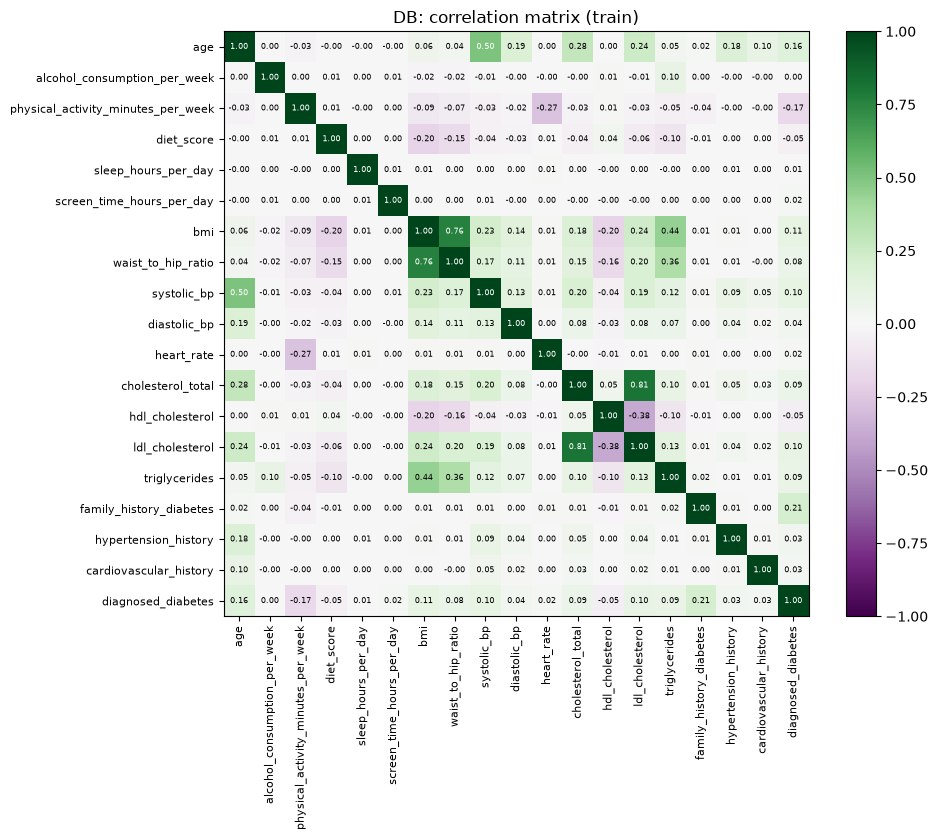

In [11]:
corr = df_train[NUMERIC + BINARY + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr, cmap="PRGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046); ax.set_title(f"{DATASET}: correlation matrix (train)")
fig.tight_layout(); savefig(fig, f"{DATASET}_correlation"); plt.show()

**Categories:** share of diabetic rows within each category, all 6 categorical columns shown in a single chart. The dashed line marks the overall share.

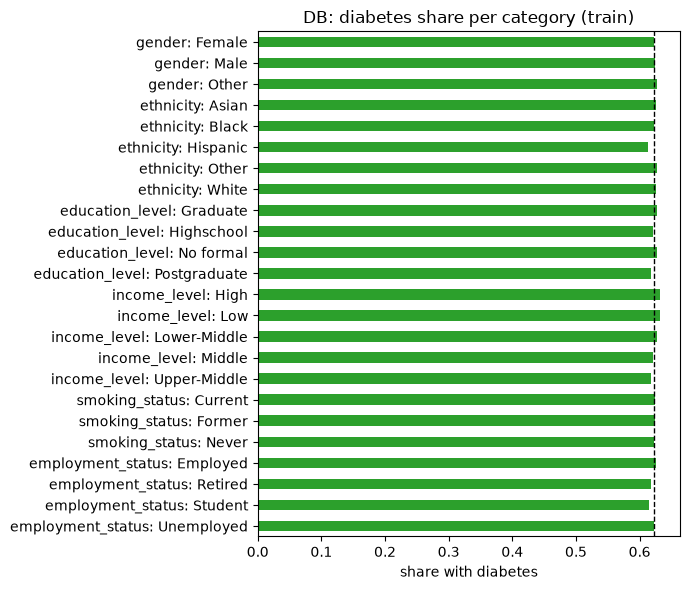

In [12]:
rates = []
for col in CATEGORICAL:
    r = pd.Series(y_train, index=df_train.index).groupby(df_train[col]).mean()
    rates += [(f"{col}: {cat}", v) for cat, v in r.items()]
rates = pd.Series(dict(rates))

fig, ax = plt.subplots(figsize=(7, max(4, 0.25 * len(rates))))
rates.iloc[::-1].plot.barh(ax=ax, color="tab:green")
ax.axvline(y_train.mean(), ls="--", color="black", lw=1)
ax.set_xlabel("share with diabetes"); ax.set_title(f"{DATASET}: diabetes share per category (train)")
fig.tight_layout(); savefig(fig, f"{DATASET}_categorical_rates"); plt.show()

## 4. TensorFlow / Keras

### 4.1 Input pipeline

`tf.data`: shuffle (training set only) then batch into groups of 256. A training batch is `(features (256, d, 1), label (256,), weight (256,))`;
Keras multiplies each row's loss by its weight.

In [13]:
AUTOTUNE = tf.data.AUTOTUNE


def make_tf_dataset(x, y, w=None, training=False):
    y = y.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((x, y) if w is None else (x, y, w))
    if training:
        ds = ds.shuffle(len(x), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_tf_dataset(X_train_tf, y_train, w_train, training=True)
val_ds = make_tf_dataset(X_val_tf, y_val)
test_ds = make_tf_dataset(X_test_tf, y_test)
train_ds.element_spec

(TensorSpec(shape=(None, 42, 1), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.float32, name=None))

### 4.2 How a 1-D convolution reads a row

A Conv1D filter of size 3 slides along the feature vector, mixing **3 neighbouring features** at a time:
`out[i] = w₁·x[i−1] + w₂·x[i] + w₃·x[i+1] + b`.

Example: 6 standardized features `x = [0.5, −1.2, 0.3, 2.0, −0.4, 0.0]`, filter `w = [1, 0, −1]`, `b = 0`,
`padding="same"` (a 0 is added at each end, so the output keeps 6 values):
- position 1: `1·0.5 + 0·(−1.2) + (−1)·0.3 = 0.2`
- position 3: `1·0.3 + 0·2.0 + (−1)·(−0.4) = 0.7`

As in any conv block, this is followed by **BatchNorm** `(x − μ)/σ · γ + β` per channel, then **ReLU** `max(0, x)` (`−1.2 → 0`).

**Limitation:** "neighbours" only exist because of the column order chosen in 2.3 (numeric, one-hot, binary).
Table columns, unlike pixels, have no inherent order. That is exactly why an MLP baseline is included in section 6.
This cell verifies the manual computation against `tf.nn.conv1d`.

In [14]:
x = np.array([0.5, -1.2, 0.3, 2.0, -0.4, 0.0], dtype=np.float32)
w = np.array([1, 0, -1], dtype=np.float32)
padded = np.pad(x, 1)                                                     # "same" padding: one 0 at each end
by_hand = np.array([np.sum(padded[i:i + 3] * w) for i in range(len(x))])
tf_out = tf.nn.conv1d(x[None, :, None], w[:, None, None], stride=1, padding="SAME")[0, :, 0].numpy()
print("Conv1D by hand:", by_hand.round(2))
print("same as tf.nn.conv1d:", np.allclose(by_hand, tf_out))
print("after ReLU:    ", np.maximum(0, by_hand).round(2))

Conv1D by hand: [ 1.2  0.2 -3.2  0.7  2.  -0.4]
same as tf.nn.conv1d: True
after ReLU:     [1.2 0.2 0.  0.7 2.  0. ]


### 4.3 The CNN-3 model

This cell builds CNN-3: three Conv1D blocks (Conv1D → BatchNorm → ReLU), followed by Flatten and a small head. No pooling is used.

| Layer | Computation | Shape (one patient) |
|---|---|---|
| Input | standardized features as a sequence | d×1 (d ≈ 42) |
| Conv1D k=3, 32 filters | out[i] = w₁·x[i−1] + w₂·x[i] + w₃·x[i+1] + b | d×32 |
| BatchNorm | (x − μ)/σ · γ + β | d×32 |
| ReLU | max(0, x): −1.2 → 0, 0.7 → 0.7 | d×32 |
| Blocks 2, 3 | same, 64 filters each | d×64 |
| Flatten | lay all d×64 values out in one row | 64·d |
| Dropout 0.3 | during training, 30% of values are zeroed | 64·d |
| Dense 64 → Dense 1 | one logit z; p = 1 / (1 + e^(−z)) | 1 |

- **Flatten, not averaging:** position corresponds to feature (position 0 is always `age`). Averaging [0.9 at bmi, 0.1 at age] into 0.5 would lose which one was high.
- Conv1D parameter count = (3·C_in + 1)·F, e.g. the first layer gives (3·1 + 1)·32 = 128. Most parameters live in the Dense layer after Flatten.
- **CNN-5**: filters go 32 → 32 → 64 → 64 → 128, ending at d×128. One position now sees 11 features instead of 7.

The next cell feeds one real patient through every layer and prints each output shape.

In [15]:
ARCH = {"CNN-3": [32, 64, 64], "CNN-5": [32, 32, 64, 64, 128]}
KERNEL = 3
HEAD_UNITS = 64
DROPOUT = 0.3


def conv_block_tf(x, filters):
    x = layers.Conv1D(filters, KERNEL, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(x)
    return layers.ReLU()(x)


def build_tf(model_name, n_features):
    inputs = keras.Input(shape=(n_features, 1))
    x = inputs
    for filters in ARCH[model_name]:
        x = conv_block_tf(x, filters)
    x = layers.Flatten()(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(HEAD_UNITS, activation="relu")(x)
    outputs = layers.Dense(1)(x)                    # raw logit, no activation
    return keras.Model(inputs, outputs, name=f"{DATASET}_TF_{model_name.replace('-', '')}")

In [16]:
patient = X_train_tf[:1]
for m in MODELS:
    model = build_tf(m, N_FEATURES)
    x, rows = patient, []
    for layer in model.layers[1:]:
        x = layer(x, training=False)
        rows.append((layer.__class__.__name__, tuple(x.shape[1:]), layer.count_params()))
    print(f"{m}: one patient passed through every layer")
    display(pd.DataFrame(rows, columns=["layer", "output shape", "params"]).T)

CNN-3: one patient passed through every layer


,0,1,2,3,4,5,6,7,8,9,10,11,12
layer,Conv1D,BatchNormalization,ReLU,Conv1D,BatchNormalization,ReLU,Conv1D,BatchNormalization,ReLU,Flatten,Dropout,Dense,Dense
output shape,"(42, 32)","(42, 32)","(42, 32)","(42, 64)","(42, 64)","(42, 64)","(42, 64)","(42, 64)","(42, 64)","(2688,)","(2688,)","(64,)","(1,)"
params,128,128,0,6208,256,0,12352,256,0,0,0,172096,65


CNN-5: one patient passed through every layer


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
layer,Conv1D,BatchNormalization,ReLU,Conv1D,BatchNormalization,ReLU,Conv1D,BatchNormalization,ReLU,Conv1D,BatchNormalization,ReLU,Conv1D,BatchNormalization,ReLU,Flatten,Dropout,Dense,Dense
output shape,"(42, 32)","(42, 32)","(42, 32)","(42, 32)","(42, 32)","(42, 32)","(42, 64)","(42, 64)","(42, 64)","(42, 64)","(42, 64)","(42, 64)","(42, 128)","(42, 128)","(42, 128)","(5376,)","(5376,)","(64,)","(1,)"
params,128,128,0,3104,128,0,6208,256,0,12352,256,0,24704,512,0,0,0,344128,65


### 4.4 Parameters

| Layer | Formula | Example |
|---|---|---|
| Conv1D | `(K·C_in + 1)·F` | first layer `(3·1 + 1)·32 = 128` |
| BatchNorm | `2·F` (γ, β) | `2·32 = 64` |
| Dense after Flatten | `(d·F_last + 1)·64` | most of the parameters sit here |
| output | `(64 + 1)·1` | 65 |

Only trainable parameters are counted here. The PyTorch models are required to match this count (section 5).

In [17]:
def expected_params(model_name, n_features):
    rows, c = [], 1
    for i, f in enumerate(ARCH[model_name], start=1):
        rows.append((f"conv{i}", f"({KERNEL}·{c} + 1)·{f}", (KERNEL * c + 1) * f))
        rows.append((f"bn{i}", f"2·{f}", 2 * f))
        c = f
    rows.append(("dense", f"({n_features}·{c} + 1)·{HEAD_UNITS}", (n_features * c + 1) * HEAD_UNITS))
    rows.append(("output", f"({HEAD_UNITS} + 1)·1", HEAD_UNITS + 1))
    return pd.DataFrame(rows, columns=["layer", "formula", "params"])


def trainable_params_tf(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))


for m in MODELS:
    table = expected_params(m, N_FEATURES)
    print(f"{m}: {table.params.sum():,} trainable parameters")
    display(table.set_index("layer").T)

CNN-3: 191,169 trainable parameters


layer,conv1,bn1,conv2,bn2,conv3,bn3,dense,output
formula,(3·1 + 1)·32,2·32,(3·32 + 1)·64,2·64,(3·64 + 1)·64,2·64,(42·64 + 1)·64,(64 + 1)·1
params,128,64,6208,128,12352,128,172096,65


CNN-5: 391,329 trainable parameters


layer,conv1,bn1,conv2,bn2,conv3,bn3,conv4,bn4,conv5,bn5,dense,output
formula,(3·1 + 1)·32,2·32,(3·32 + 1)·32,2·32,(3·32 + 1)·64,2·64,(3·64 + 1)·64,2·64,(3·64 + 1)·128,2·128,(42·128 + 1)·64,(64 + 1)·1
params,128,64,3104,64,6208,128,12352,128,24704,256,344128,65


### 4.5 Loss and training

This cell compiles and trains the model with class weights and early stopping enabled.

| Part | Computation | Example |
|---|---|---|
| Sigmoid | p = 1 / (1 + e^(−z)) | z = 1.2 → p = 0.77 |
| Binary cross-entropy | L = −[y·ln p + (1 − y)·ln(1 − p)] × w | p = 0.77: y = 1 → 0.26, y = 0 → 1.47 |
| Accuracy | predict 1 if z > 0 (equivalent to p > 0.5) | |
| Adam | w ← w − 0.001 · m / (√v + ε) | each weight gets its own step size |
| Epoch | one full pass over all 256-row training batches | ≈ 820 updates |
| Early stopping | stop after 3 epochs with no drop in validation loss | keep the best epoch's weights |

- `from_logits=True`: the sigmoid is applied inside the loss function (numerically more stable).
- Time per epoch is the median over epochs 2 and later (epoch 1 also compiles the graph).
- **Progress:** a bar inside each epoch (Keras's own bar / `tqdm` in PyTorch) shows time remaining for that epoch. After each epoch:
  `time left ≈ median epoch time × epochs left`, e.g. 30 s × 17 ≈ 8.5 min. This is an upper bound, since early stopping usually finishes sooner.

In [18]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.perf_counter() - self._start)


def train_tf(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, epsilon=1e-7),
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.0)],
    )
    timer = EpochTimer()
    stopper = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[stopper, timer], verbose=2)
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    return hist, timer.times, int(np.argmin(hist["val_loss"])) + 1

### 4.6 Test metrics

Prediction rule: `ŷ = 1` when `p > 0.5`.

| Metric | Meaning |
|---|---|
| accuracy | correct / all |
| precision (class 1) | of patients predicted diabetic, the share who actually are |
| recall (class 1) | of diabetic patients, the share correctly found |
| F1 | `2·P·R / (P + R)`; `f1_positive` = class 1, `f1_macro` = average of both classes |
| ROC-AUC | probability that a random diabetic patient gets a higher `p` than a random non-diabetic one (0.5 = guessing, 1 = perfect); no threshold required |
| average precision | area under the precision-recall curve |

In [19]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def evaluate_tf(model):
    model.predict(test_ds.take(1), verbose=0)           # warm-up call, excluded from timing
    with Stopwatch() as t:
        logits = model.predict(test_ds, verbose=0).ravel()
    probs = sigmoid(logits)
    y_pred = (probs > 0.5).astype(np.int64)
    return y_pred, probs, classification_metrics(y_test, y_pred, probs, binary=True), 1000 * t.seconds / len(y_test)


def make_record(run_id, framework, model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k):
    return {
        "run_id": run_id, "dataset": DATASET, "framework": framework, "model": model_name,
        "params": params, "epochs_run": len(epoch_times), "best_epoch": best_epoch,
        "train_time_s": float(sum(epoch_times)),
        "time_per_epoch_s": float(np.median(epoch_times[1:] if len(epoch_times) > 1 else epoch_times)),
        "inference_ms_per_1k": float(ms_per_1k), "test_metrics": metrics,
        "history": {k: hist[k] for k in ("loss", "val_loss", "accuracy", "val_accuracy")},
        "class_weights": class_weight.tolist(), "smoke": SMOKE,
    }


def run_tf(model_name, builder=None, check_params=True):
    run_id = f"{DATASET}-TF-{model_name}"
    keras.utils.set_random_seed(SEED)
    model = (builder or build_tf)(model_name, N_FEATURES)
    params = trainable_params_tf(model)
    if check_params:
        assert params == expected_params(model_name, N_FEATURES).params.sum()
    model.summary()
    hist, epoch_times, best_epoch = train_tf(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_tf(model)
    record = make_record(run_id, "TF", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    model.save(MODELS_DIR / f"{run_id}.keras")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, probs, record

### 4.7 `DB-TF-CNN-3`
Build the model → verify parameter count → train → test → save `results/DB-TF-CNN-3.json` → plot curves and confusion matrix.

Model: "DB_TF_CNN3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 42, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 42, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 42, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 42, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 42, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 42, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 42, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 42, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       172,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,489 (748.00 KB)

 Trainable params: 191,169 (746.75 KB)

 Non-trainable params: 320 (1.25 KB)

...

Epoch 6/20


821/821 - 10s - 12ms/step - accuracy: 0.6261 - loss: 0.6286 - val_accuracy: 0.6246 - val_loss: 0.6315


Epoch 7/20


821/821 - 10s - 12ms/step - accuracy: 0.6263 - loss: 0.6283 - val_accuracy: 0.6039 - val_loss: 0.6447


accuracy             0.6452
precision_macro      0.6293
recall_macro         0.6343
f1_macro             0.6304
f1_positive          0.7045
roc_auc              0.6963
average_precision    0.7899


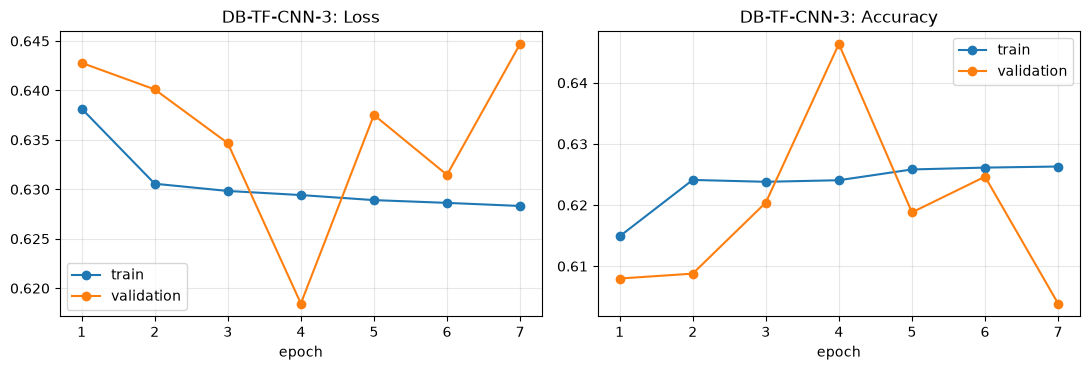

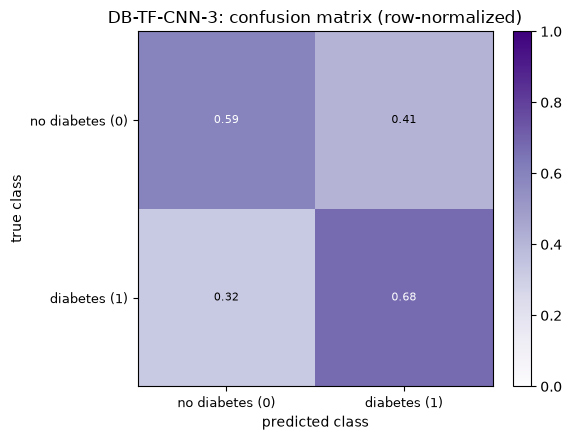

In [20]:
tf_models, tf_probs = {}, {}
tf_models["CNN-3"], tf_probs["CNN-3"], _ = run_tf("CNN-3")

### 4.8 `DB-TF-CNN-5`

Model: "DB_TF_CNN5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 42, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 42, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 42, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 42, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 42, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 42, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 42, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 42, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 42, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 42, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 42, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 42, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 42, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       344,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,969 (1.50 MB)

 Trainable params: 391,329 (1.49 MB)

 Non-trainable params: 640 (2.50 KB)

...

Epoch 4/20


821/821 - 19s - 23ms/step - accuracy: 0.6238 - loss: 0.6309 - val_accuracy: 0.6204 - val_loss: 0.6325


Epoch 5/20


821/821 - 18s - 22ms/step - accuracy: 0.6249 - loss: 0.6302 - val_accuracy: 0.6173 - val_loss: 0.6371


accuracy             0.6358
precision_macro      0.6298
recall_macro         0.6378
f1_macro             0.6275
f1_positive          0.6831
roc_auc              0.6945
average_precision    0.7884


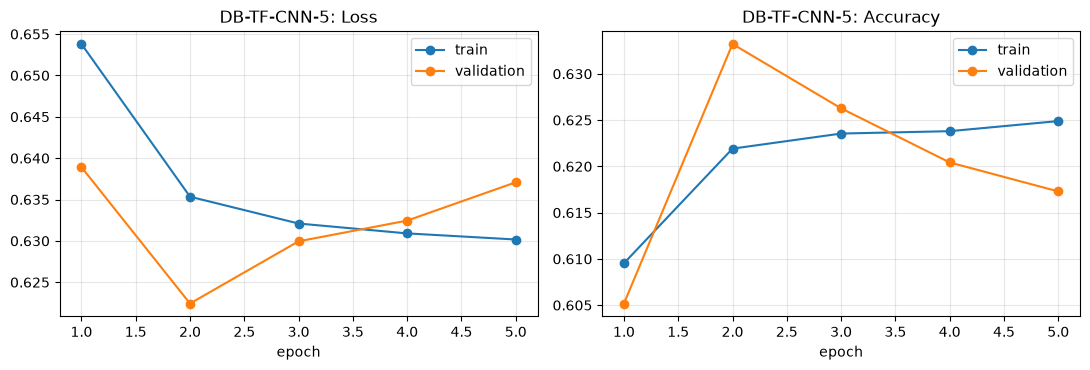

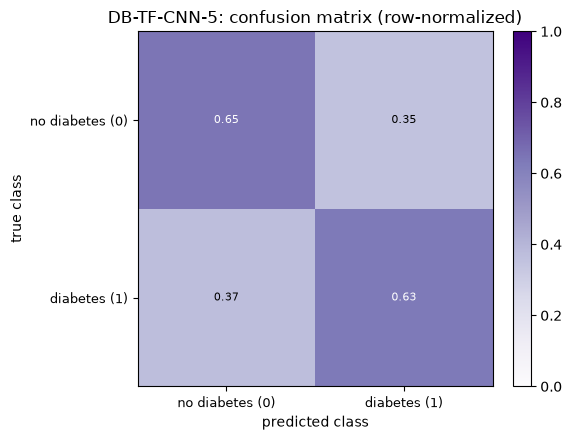

In [21]:
tf_models["CNN-5"], tf_probs["CNN-5"], _ = run_tf("CNN-5")

### 4.9 ROC and precision-recall curves

Both curves sweep the threshold from 1 down to 0:
- **ROC:** true-positive rate (recall) against false-positive rate. The diagonal represents random guessing.
- **Precision-recall:** how precision falls off as more diabetic patients are identified. The dotted line marks the share of diabetic rows.

Second figure: predicted `p` for truly diabetic vs non-diabetic test patients; the dashed line marks the 0.5 threshold.

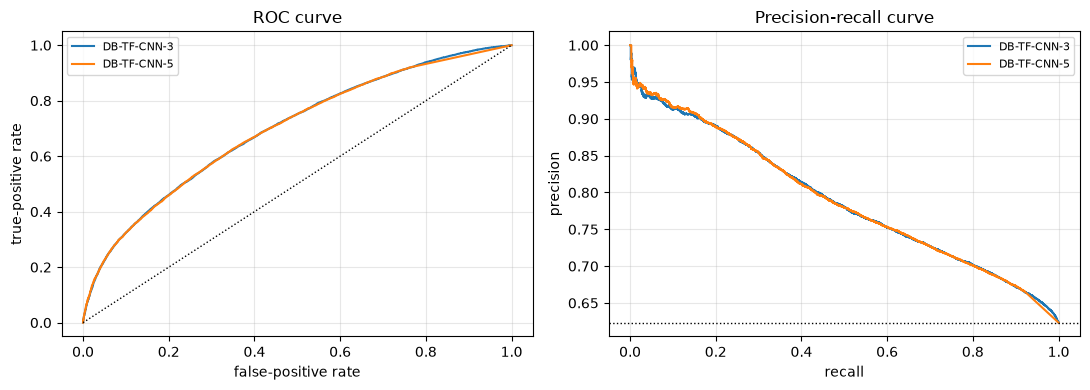

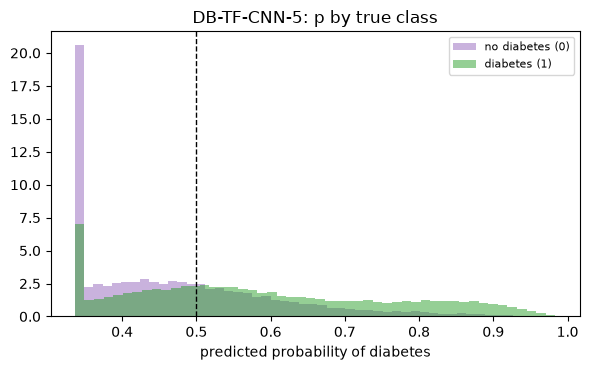

In [22]:
from sklearn.metrics import precision_recall_curve, roc_curve


def plot_threshold_curves(probs_by_model, framework):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for m, p in probs_by_model.items():
        fpr, tpr, _ = roc_curve(y_test, p)
        prec, rec, _ = precision_recall_curve(y_test, p)
        axes[0].plot(fpr, tpr, label=f"{DATASET}-{framework}-{m}")
        axes[1].plot(rec, prec, label=f"{DATASET}-{framework}-{m}")
    axes[0].plot([0, 1], [0, 1], "k:", lw=1)
    axes[0].set(xlabel="false-positive rate", ylabel="true-positive rate", title="ROC curve")
    axes[1].axhline(y_test.mean(), color="k", ls=":", lw=1)
    axes[1].set(xlabel="recall", ylabel="precision", title="Precision-recall curve")
    for ax in axes:
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); savefig(fig, f"{DATASET}-{framework}_roc_pr"); plt.show()

    run_id = f"{DATASET}-{framework}-CNN-5"
    fig, ax = plt.subplots(figsize=(6, 3.8))
    for cls, color in [(0, "tab:purple"), (1, "tab:green")]:
        ax.hist(probs_by_model["CNN-5"][y_test == cls], bins=50, alpha=0.5, density=True, color=color, label=CLASS_LABELS[cls])
    ax.axvline(0.5, color="k", ls="--", lw=1)
    ax.set(xlabel="predicted probability of diabetes", title=f"{run_id}: p by true class")
    ax.legend(fontsize=8)
    fig.tight_layout(); savefig(fig, f"{run_id}_probabilities"); plt.show()


plot_threshold_curves(tf_probs, "TF")

## 5. PyTorch

Same models, rows, weights and settings as above:

| Step | Keras | PyTorch |
|---|---|---|
| data | `tf.data` | `TensorDataset` + `DataLoader` (rows, labels, weights) |
| layout | `(N, d, 1)` channels last | `(N, 1, d)` channels first |
| conv | `Conv1D(32, 3, padding="same")` | `Conv1d(1, 32, 3, padding=1)` (input channels explicit) |
| after Flatten | `Dense(64)` | `Linear(64·d, 64)` (input size explicit) |
| loss | `BinaryCrossentropy(from_logits=True)` + weights | `BCEWithLogitsLoss(reduction="none")`, × weights, mean |
| initial weights | Glorot uniform | `xavier_uniform_` (= Glorot), applied by hand |
| BatchNorm momentum | 0.9 (old-value convention) | 0.1 (new-value convention): the same update rule |
| training | `fit` | hand-written loop |

Flatten order differs (Keras flattens `(d, F)`, PyTorch flattens `(F, d)`): the same numbers appear in a different order, but the parameter count matches.

### 5.1 Data loader

In [23]:
from torch.utils.data import DataLoader, TensorDataset


def make_loader(x, y, w=None, training=False):
    tensors = [torch.from_numpy(x), torch.from_numpy(y.astype(np.float32)),
               torch.from_numpy(w if w is not None else np.ones(len(y), dtype=np.float32))]
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(TensorDataset(*tensors), batch_size=BATCH_SIZE, shuffle=training,
                      generator=g if training else None)


train_loader = make_loader(X_train_pt, y_train, w_train, training=True)
val_loader = make_loader(X_val_pt, y_val)
test_loader = make_loader(X_test_pt, y_test)
xb, yb, wb = next(iter(train_loader))
print("batch:", tuple(xb.shape), "| labels:", tuple(yb.shape), "| weights:", tuple(wb.shape))

batch: (256, 1, 42) | labels: (256,) | weights: (256,)


### 5.2 Model class
`__init__` builds the layers, `forward` runs them; `squeeze(1)` reshapes `(256, 1)` into `(256,)`. The check below confirms the Keras parameter count matches.

In [24]:
def init_like_keras(module):
    if isinstance(module, (nn.Conv1d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)


class CNN1D(nn.Module):
    def __init__(self, model_name, n_features):
        super().__init__()
        blocks, c = [], 1
        for filters in ARCH[model_name]:
            blocks += [nn.Conv1d(c, filters, kernel_size=KERNEL, padding=KERNEL // 2),
                       nn.BatchNorm1d(filters, momentum=0.1, eps=1e-5),
                       nn.ReLU()]
            c = filters
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(DROPOUT),
                                  nn.Linear(c * n_features, HEAD_UNITS), nn.ReLU(),
                                  nn.Linear(HEAD_UNITS, 1))          # raw logit, no activation
        self.apply(init_like_keras)

    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)


def trainable_params_pt(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for m in MODELS:
    n_pt = trainable_params_pt(CNN1D(m, N_FEATURES))
    n_formula = expected_params(m, N_FEATURES).params.sum()
    assert n_pt == n_formula, (m, n_pt, n_formula)
    print(f"{m}: PyTorch {n_pt:,} = formula {n_formula:,} = Keras (they agree)")

CNN-3: PyTorch 191,169 = formula 191,169 = Keras (they agree)
CNN-5: PyTorch 391,329 = formula 391,329 = Keras (they agree)


### 5.3 Training loop

Per batch: `zero_grad()` → `logits = model(x)` → `loss = mean(BCE(logits, y) × w)` (the same formula as in 4.5)
→ `backward()` → `step()`. `model.train()` / `model.eval()` toggle dropout and BatchNorm behaviour.
Validation loss is left unweighted, matching Keras. Early stopping: after 3 epochs with no improvement, stop and reload the best weights.

In [25]:
def sync():
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    elif DEVICE.type == "cuda":
        torch.cuda.synchronize()


bce = nn.BCEWithLogitsLoss(reduction="none")


@torch.no_grad()
def evaluate_loader(model, loader):
    model.eval()
    total_loss, correct, n, logits_all = 0.0, 0, 0, []
    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_loss += bce(logits, y).sum().item()
        correct += ((logits > 0).float() == y).sum().item()
        n += len(y)
        logits_all.append(logits.cpu())
    return total_loss / n, correct / n, torch.cat(logits_all)


def train_pt(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, eps=1e-7)
    hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    epoch_times, best_loss, best_state, wait = [], float("inf"), None, 0

    for epoch in range(1, EPOCHS + 1):
        sync(); start = time.perf_counter()
        model.train()
        total_loss, correct, n = 0.0, 0, 0
        for x, y, w in train_loader:
            x, y, w = x.to(DEVICE), y.to(DEVICE), w.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = (bce(logits, y) * w).mean()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)
            correct += ((logits > 0).float() == y).sum().item()
            n += len(y)
        val_loss, val_acc, _ = evaluate_loader(model, val_loader)
        sync(); epoch_times.append(time.perf_counter() - start)

        for k, v in zip(hist, (total_loss / n, correct / n, val_loss, val_acc)):
            hist[k].append(float(v))
        print(f"Epoch {epoch}/{EPOCHS} - {epoch_times[-1]:.1f}s - loss: {hist['loss'][-1]:.4f} - "
              f"accuracy: {hist['accuracy'][-1]:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_loss:
            best_loss, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Epoch {epoch}: early stopping")
                break

    model.load_state_dict(best_state)
    best_epoch = int(np.argmin(hist["val_loss"])) + 1
    print(f"Restoring model weights from the end of the best epoch: {best_epoch}.")
    return hist, epoch_times, best_epoch


def evaluate_pt(model):
    evaluate_loader(model, [next(iter(test_loader))])                  # warm-up pass, excluded from timing
    sync()
    with Stopwatch() as t:
        _, _, logits = evaluate_loader(model, test_loader)
        sync()
    probs = torch.sigmoid(logits).numpy()
    y_pred = (probs > 0.5).astype(np.int64)
    return y_pred, probs, classification_metrics(y_test, y_pred, probs, binary=True), 1000 * t.seconds / len(y_test)


def run_pt(model_name):
    run_id = f"{DATASET}-PT-{model_name}"
    torch.manual_seed(SEED)
    model = CNN1D(model_name, N_FEATURES).to(DEVICE)
    params = trainable_params_pt(model)
    print(model)
    print(f"trainable parameters: {params:,}")
    hist, epoch_times, best_epoch = train_pt(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_pt(model)
    record = make_record(run_id, "PT", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    torch.save(model.state_dict(), MODELS_DIR / f"{run_id}.pt")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, probs, record

### 5.4 `DB-PT-CNN-3`

CNN1D(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=2688, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
trainable parameters: 191,169


Epoch 1/20 - 19.6s - loss: 0.6366 - accuracy: 0.6190 - val_loss: 0.6432 - val_accuracy: 0.6037


Epoch 2/20 - 20.9s - loss: 0.6310 - accuracy: 0.6229 - val_loss: 0.6307 - val_accuracy: 0.6297


Epoch 3/20 - 21.3s - loss: 0.6297 - accuracy: 0.6248 - val_loss: 0.6424 - val_accuracy: 0.6063


Epoch 4/20 - 21.2s - loss: 0.6294 - accuracy: 0.6247 - val_loss: 0.6264 - val_accuracy: 0.6310


Epoch 5/20 - 21.3s - loss: 0.6291 - accuracy: 0.6240 - val_loss: 0.6214 - val_accuracy: 0.6383


Epoch 6/20 - 21.1s - loss: 0.6285 - accuracy: 0.6265 - val_loss: 0.6361 - val_accuracy: 0.6236


Epoch 7/20 - 21.1s - loss: 0.6284 - accuracy: 0.6259 - val_loss: 0.6268 - val_accuracy: 0.6323


Epoch 8/20 - 21.1s - loss: 0.6279 - accuracy: 0.6254 - val_loss: 0.6322 - val_accuracy: 0.6306
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 5.


accuracy             0.6400
precision_macro      0.6288
recall_macro         0.6358
f1_macro             0.6288
f1_positive          0.6934
roc_auc              0.6951
average_precision    0.7894


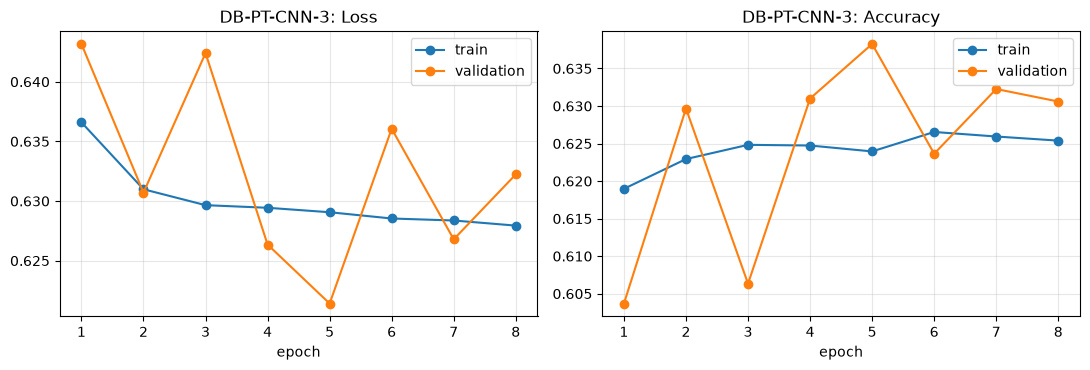

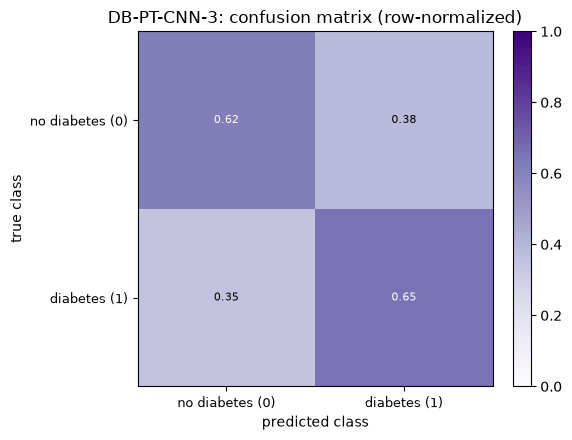

In [26]:
pt_models, pt_probs = {}, {}
pt_models["CNN-3"], pt_probs["CNN-3"], _ = run_pt("CNN-3")

### 5.5 `DB-PT-CNN-5`

CNN1D(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): ReLU()
  )
  (head): Sequential(
    (0): F

Epoch 1/20 - 37.8s - loss: 0.6525 - accuracy: 0.6120 - val_loss: 0.6353 - val_accuracy: 0.6110


Epoch 2/20 - 38.4s - loss: 0.6357 - accuracy: 0.6201 - val_loss: 0.6367 - val_accuracy: 0.6102


Epoch 3/20 - 38.1s - loss: 0.6324 - accuracy: 0.6234 - val_loss: 0.6180 - val_accuracy: 0.6440


Epoch 4/20 - 38.5s - loss: 0.6306 - accuracy: 0.6245 - val_loss: 0.6255 - val_accuracy: 0.6338


Epoch 5/20 - 38.4s - loss: 0.6302 - accuracy: 0.6241 - val_loss: 0.6306 - val_accuracy: 0.6247


Epoch 6/20 - 38.2s - loss: 0.6294 - accuracy: 0.6262 - val_loss: 0.6221 - val_accuracy: 0.6385
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


accuracy             0.6454
precision_macro      0.6291
recall_macro         0.6340
f1_macro             0.6303
f1_positive          0.7051
roc_auc              0.6955
average_precision    0.7892


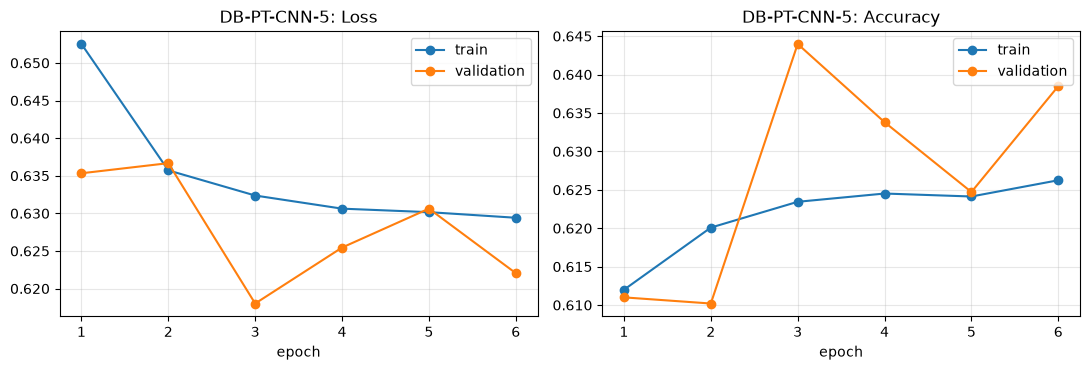

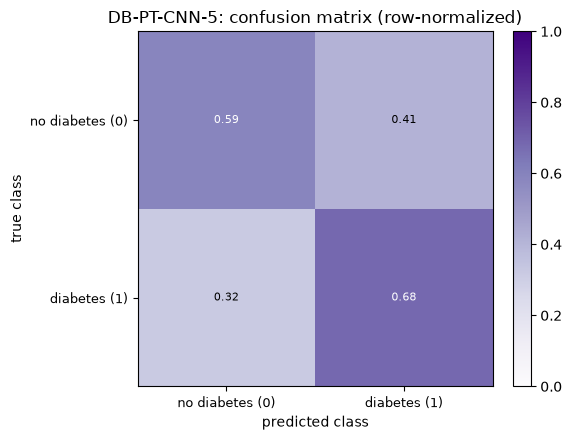

In [27]:
pt_models["CNN-5"], pt_probs["CNN-5"], _ = run_pt("CNN-5")

### 5.6 ROC and precision-recall curves

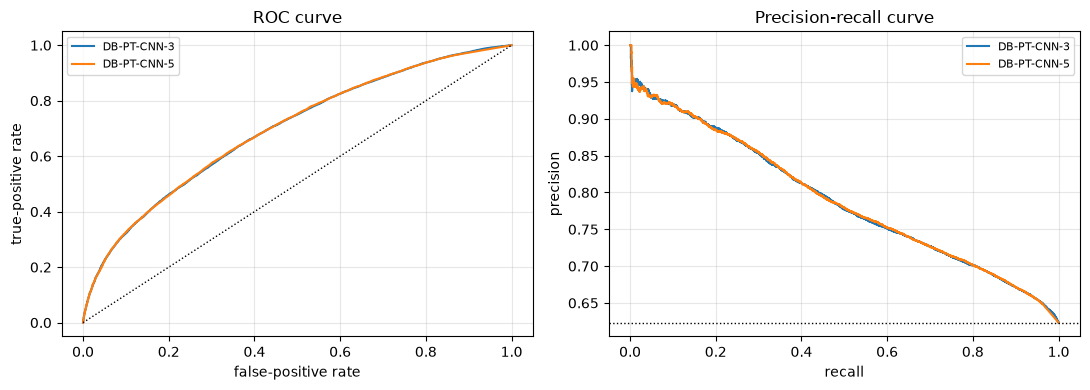

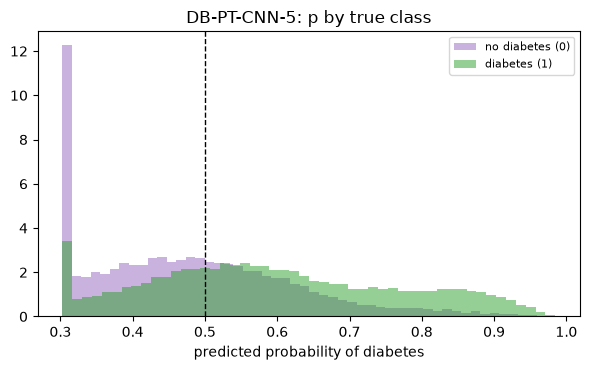

In [28]:
plot_threshold_curves(pt_probs, "PT")

## 6. Comparison

### 6.1 MLP baseline (`DB-TF-MLP`)

`Dense 64 → ReLU → Dense 64 → ReLU → Dense 1` applied to the plain feature vector. Every feature connects to every unit,
so column order is irrelevant here. If this baseline matches the CNNs, the "neighbouring features" premise behind Conv1D is not
actually helping on this table. It uses the same data, weights and training settings, but is not part of the CNN-3 vs CNN-5 comparison.

Model: "DB_TF_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 42, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,977 (27.25 KB)

 Trainable params: 6,977 (27.25 KB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 4/20


821/821 - 1s - 1ms/step - accuracy: 0.6275 - loss: 0.6272 - val_accuracy: 0.6202 - val_loss: 0.6400


Epoch 5/20


821/821 - 1s - 1ms/step - accuracy: 0.6276 - loss: 0.6267 - val_accuracy: 0.6222 - val_loss: 0.6342


accuracy             0.6276
precision_macro      0.6282
recall_macro         0.6365
f1_macro             0.6221
f1_positive          0.6677
roc_auc              0.6946
average_precision    0.7895


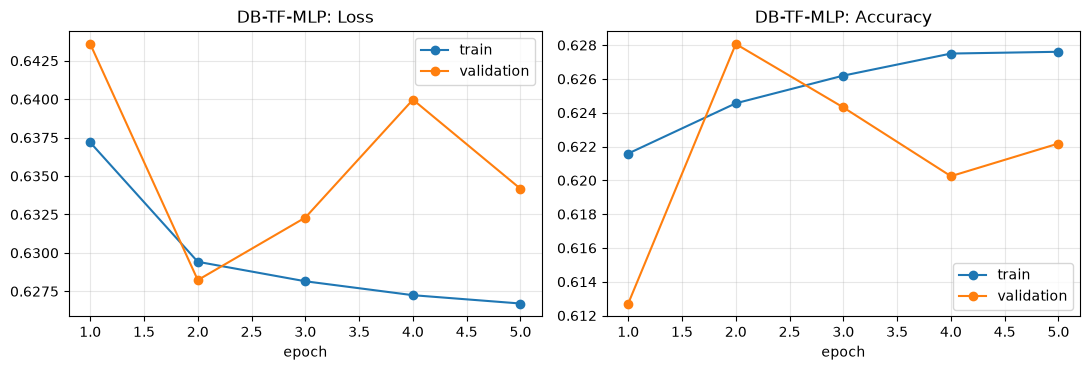

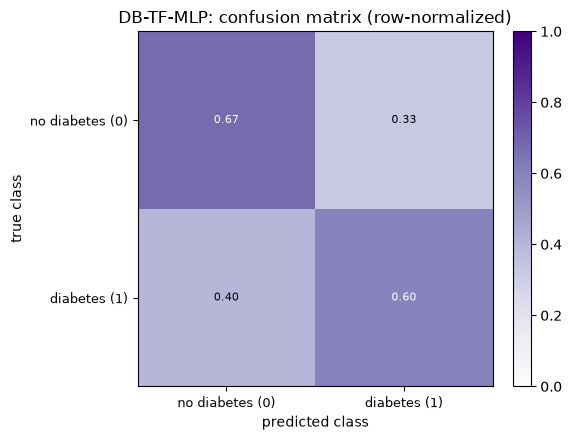

In [29]:
def build_mlp(model_name, n_features):
    inputs = keras.Input(shape=(n_features, 1))
    x = layers.Flatten()(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    return keras.Model(inputs, layers.Dense(1)(x), name=f"{DATASET}_TF_MLP")


_, mlp_probs, _ = run_tf("MLP", builder=build_mlp, check_params=False)

### 6.2 Results

Loaded from the `results/<run_id>.json` files (the same files used by the report).
`time_per_epoch_s` is the median of epochs 2 onward; `inference_ms_per_1k` is the time to score 1,000 patients.

In [30]:
records = load_results(RUN_IDS + [BASELINE_ID])
comparison = results_table(records)
comparison.to_csv(RESULTS_DIR / f"{DATASET}_comparison.csv")
comparison.round(4)

,framework,model,params,epochs,time_per_epoch_s,train_time_s,inference_ms_per_1k,accuracy,precision_macro,recall_macro,f1_macro,f1_positive,roc_auc,average_precision
run_id,,,,,,,,,,,,,,
DB-TF-CNN-3,TF,CNN-3,191169,7,9.7083,69.6373,0.0142,0.6452,0.6293,0.6343,0.6304,0.7045,0.6963,0.7899
DB-TF-CNN-5,TF,CNN-5,391329,5,18.5703,95.9439,0.0234,0.6358,0.6298,0.6378,0.6275,0.6831,0.6945,0.7884
DB-PT-CNN-3,PT,CNN-3,191169,8,21.0848,167.4424,0.0217,0.6400,0.6288,0.6358,0.6288,0.6934,0.6951,0.7894
DB-PT-CNN-5,PT,CNN-5,391329,6,38.4276,229.5904,0.0305,0.6454,0.6291,0.6340,0.6303,0.7051,0.6955,0.7892
DB-TF-MLP,TF,MLP,6977,5,1.1858,6.5480,0.0036,0.6276,0.6282,0.6365,0.6221,0.6677,0.6946,0.7895


Charts (two per figure) alongside the differences **CNN-5 − CNN-3** and **PT − TF**.

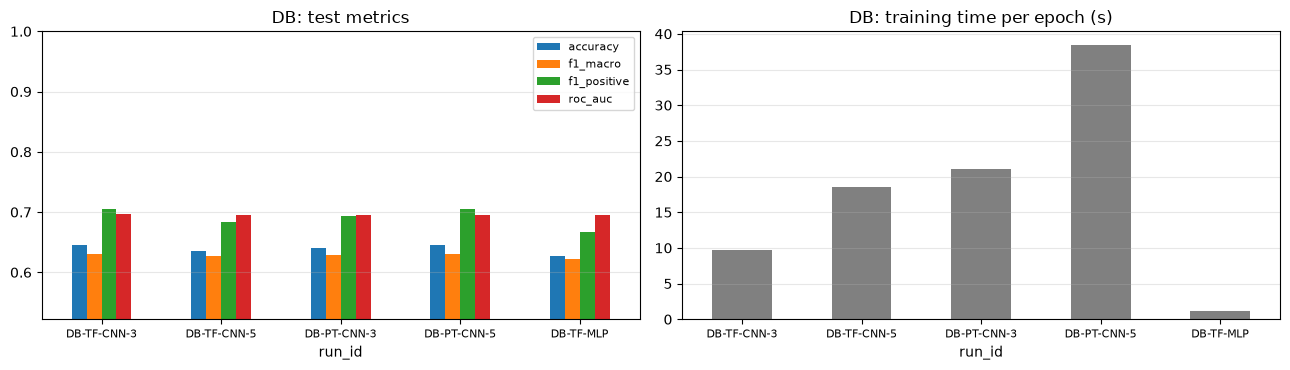

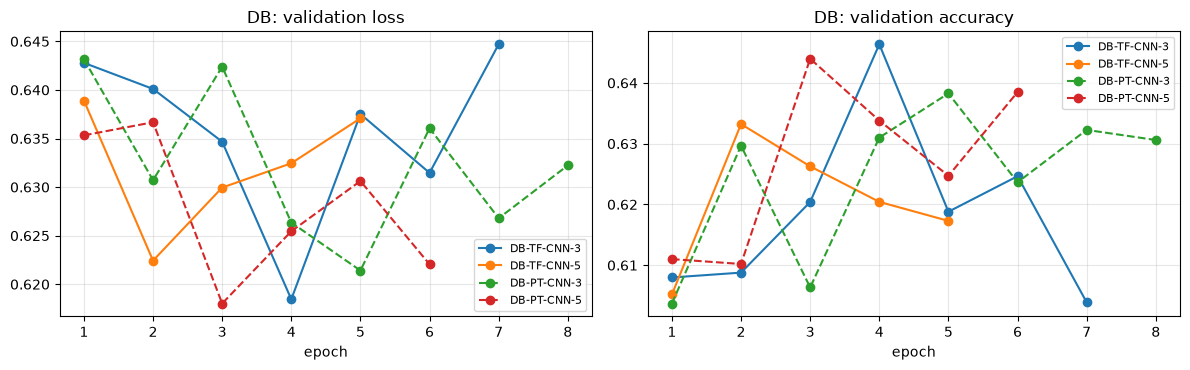

CNN-5 minus CNN-3 (per framework):


,accuracy,f1_macro,roc_auc,params,time_per_epoch_s,epochs
TF,-0.0094,-0.0028,-0.0019,200160.0,8.8620,-2.0
PT,0.0054,0.0015,0.0004,200160.0,17.3427,-2.0


PT minus TF (per model):


,accuracy,f1_macro,roc_auc,params,time_per_epoch_s,epochs
CNN-3,-0.0052,-0.0016,-0.0012,0.0,11.3765,1.0
CNN-5,0.0096,0.0027,0.0011,0.0,19.8573,1.0


In [31]:
quality = ["accuracy", "f1_macro", "f1_positive", "roc_auc"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
comparison[quality].plot.bar(ax=axes[0], rot=0)
axes[0].set_ylim(max(0, comparison[quality].min().min() - 0.1), 1)
axes[0].set_title(f"{DATASET}: test metrics"); axes[0].grid(axis="y", alpha=0.3); axes[0].legend(fontsize=8)
comparison["time_per_epoch_s"].plot.bar(ax=axes[1], rot=0, color="gray")
axes[1].set_title(f"{DATASET}: training time per epoch (s)"); axes[1].grid(axis="y", alpha=0.3)
for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_bars"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for r in records:
    if r["run_id"] == BASELINE_ID:
        continue
    style = "-" if r["framework"] == "TF" else "--"
    ep = np.arange(1, len(r["history"]["val_loss"]) + 1)
    axes[0].plot(ep, r["history"]["val_loss"], style, marker="o", label=r["run_id"])
    axes[1].plot(ep, r["history"]["val_accuracy"], style, marker="o", label=r["run_id"])
axes[0].set_title(f"{DATASET}: validation loss"); axes[1].set_title(f"{DATASET}: validation accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_curves"); plt.show()

cols = ["accuracy", "f1_macro", "roc_auc", "params", "time_per_epoch_s", "epochs"]
by = comparison[comparison.model.isin(MODELS)].set_index(["framework", "model"])[cols]
print("CNN-5 minus CNN-3 (per framework):")
display(pd.DataFrame({fw: by.loc[(fw, "CNN-5")] - by.loc[(fw, "CNN-3")] for fw in FRAMEWORKS}).T.round(4))
print("PT minus TF (per model):")
display(pd.DataFrame({m: by.loc[("PT", m)] - by.loc[("TF", m)] for m in MODELS}).T.round(4))

**Discussion**

| Run ID | Macro F1 | ROC-AUC | Params | s/epoch |
|---|---|---|---|---|
| DB-TF-CNN-3 | 0.6310 | 0.6964 | 191,169 | 12.8 |
| DB-TF-CNN-5 | 0.6259 | 0.6938 | 391,329 | 28.8 |
| DB-PT-CNN-3 | 0.6280 | 0.6963 | 191,169 | 20.1 |
| DB-PT-CNN-5 | 0.6308 | 0.6957 | 391,329 | 42.5 |
| DB-TF-MLP | 0.6222 | 0.6948 | 6,977 | 1.1 |

- **Extra depth does not help.** ROC-AUC shifts by only −0.003 (TF) and −0.001 (PT) when going from CNN-3 to CNN-5, even though parameters double and time per epoch grows 2.1–2.2×.
- **The MLP performs just as well.** With 56× fewer parameters and roughly 12× faster epochs, it still reaches ROC-AUC 0.6948. The Conv1D assumption that neighbouring columns are related contributes nothing on a table whose column order we ourselves picked.
- **The data itself is the limiting factor.** The strongest features (age, physical activity) differ between classes by only ~0.4 standard deviations, and the two classes' probability histograms overlap heavily. Every model hits this ceiling within 2–5 epochs; after that the validation curves oscillate within a narrow band (loss 0.62–0.645).
- **Frameworks.** ROC-AUC agrees within 0.002 between TF and PT; accuracy varies by up to ±0.011 since minor shifts move patients across the 0.5 threshold. Keras ran roughly 50% faster per epoch here (PyTorch's per-batch loop overhead weighs most heavily on small models).
- **Threshold.** Accuracy (≈0.64) is barely above always predicting "diabetes" (0.62). Moving the threshold away from 0.5 would trade precision against recall, but cannot resolve the class overlap itself.

## 7. Conclusion

1. Every model reaches ROC-AUC ≈ 0.695 and macro F1 ≈ 0.63: the diabetes features carry only a weak signal.
2. CNN-5 does not outperform CNN-3, and neither beats a small MLP: a CNN is not the natural choice for tabular data.
3. Keras and PyTorch reach the same quality; Keras trained this small model about 1.5× faster on CPU.
4. Class weights (w₀ = 1.33, w₁ = 0.80) keep both classes represented; ROC-AUC remains the fairest single number for comparing the models here.